In [2]:
from google.colab import files # 구글 코랩 파일접속 용

# 필요 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 코랩에서 해당 CSV파일 경로
file_path = r"/content/drive/MyDrive/Colab Notebooks/healthcare_bigdata_playbook_kr/ch08/OTg6QzA_activities.csv"


first_get_data=pd.read_csv(file_path)
print(first_get_data) # 파일 잘 가져왔는지 확인
print(first_get_data.isnull().sum()) # 결측치 있는지 확인

                     timestamp   X    Y    Z
0      2022-01-01 00:01:40.363  33   76   56
1      2022-01-01 00:01:42.961  34   87   56
2      2022-01-01 00:01:45.562  25   89   47
3      2022-01-01 00:01:48.163  11   70   50
4      2022-01-01 00:02:08.864  33   72   58
...                        ...  ..  ...  ...
66276  2022-01-31 23:28:00.481 -91  143  136
66277  2022-01-31 23:28:41.683 -89  145  138
66278  2022-01-31 23:28:49.383 -93  138  137
66279  2022-01-31 23:32:36.426 -93  131  137
66280  2022-01-31 23:32:44.126 -91  129  138

[66281 rows x 4 columns]
timestamp    0
X            0
Y            0
Z            0
dtype: int64


In [3]:
# first_get_data의 열 data 따로 저장, numpy.ndarray형태로
X = first_get_data.X.to_numpy()
Y = first_get_data.Y.to_numpy()
Z = first_get_data.Z.to_numpy()
TS = first_get_data.timestamp.to_numpy()

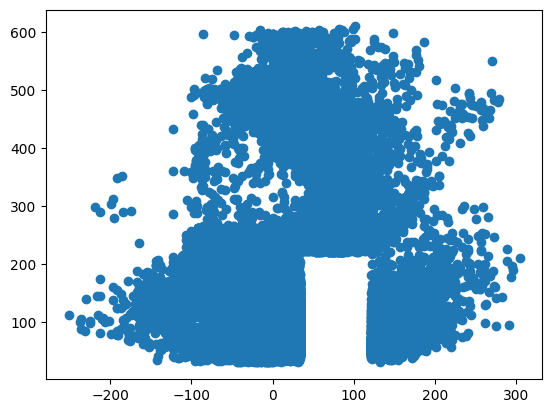

In [4]:
plt.scatter(X, Y) # X,Y Scatter 출력
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


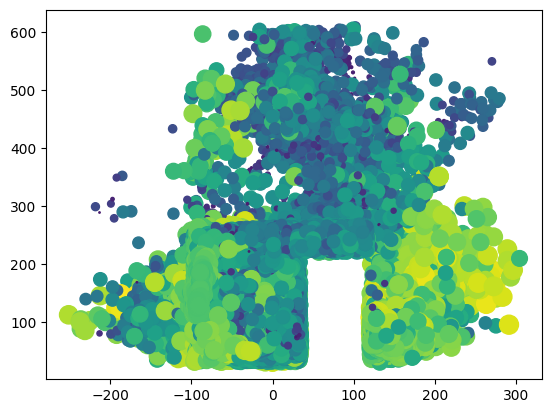

In [5]:
plt.scatter(X, Y, Z, c=Z) # 산점도 그래프 그리기
plt.show()

In [6]:
# X,Y,Z,TS data len = 66281 > 66281/4 = 16570
# X,Y,Z,TS 4등분

split4 = 66281//4 #16570

# X 4등분
Quater_X1=X[:split4]
Quater_X2=X[split4:(split4)*2]
Quater_X3=X[(split4)*2:(split4)*3]
Quater_X4=X[(split4)*3:]

# Y 4등분
Quater_Y1=Y[:split4]
Quater_Y2=Y[split4:(split4)*2]
Quater_Y3=Y[(split4)*2:(split4)*3]
Quater_Y4=Y[(split4)*3:]

# Z 4등분
Quater_Z1=Z[:split4]
Quater_Z2=Z[split4:(split4)*2]
Quater_Z3=Z[(split4)*2:(split4)*3]
Quater_Z4=Z[(split4)*3:]

# TS 4등분
Quater_TS1=TS[:split4]
Quater_TS2=TS[split4:(split4)*2]
Quater_TS3=TS[(split4)*2:(split4)*3]
Quater_TS4=TS[(split4)*3:]

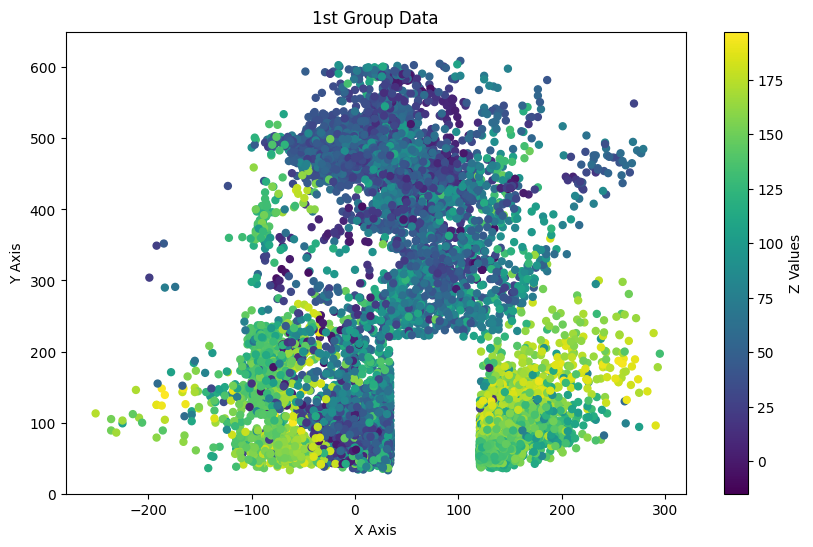

In [7]:
# 첫번째 그룹 scatter출력, Z 변화에 따라 색차이
plt.figure(figsize=(10, 6))  # 그래프 크기 조정

plt.scatter(Quater_X1, Quater_Y1, c=Quater_Z1, s=25, cmap='viridis')  # s=점 크기

plt.title("1st Group Data")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.colorbar(label="Z Values")  # 컬러바 추가 (Z축 값)

plt.xlim(-280, 320)
plt.ylim(0, 650)

plt.show()

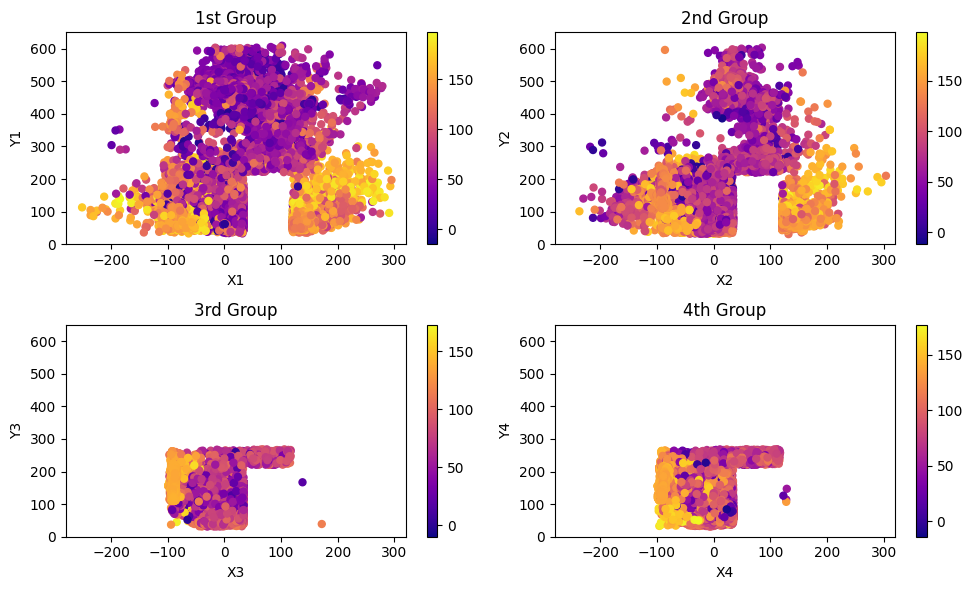

In [8]:

fig, axes = plt.subplots(2,2, figsize=(10, 6))

cmap_color_str='plasma'

# 첫 번째 scatter plot
sc1 = axes[0, 0].scatter(Quater_X1, Quater_Y1, c=Quater_Z1, s=25, cmap = cmap_color_str)
axes[0, 0].set_xlabel("X1")
axes[0, 0].set_ylabel("Y1")
axes[0, 0].set_xlim(-280, 320)
axes[0, 0].set_ylim(0, 650)
axes[0, 0].set_title("1st Group")
fig.colorbar(sc1, ax=axes[0, 0])  # 컬러바 추가

# 두 번째 scatter plot
sc2 = axes[0, 1].scatter(Quater_X2, Quater_Y2, c=Quater_Z2, s=25, cmap = cmap_color_str)
axes[0, 1].set_xlabel("X2")
axes[0, 1].set_ylabel("Y2")
axes[0, 1].set_xlim(-280, 320)
axes[0, 1].set_ylim(0, 650)
axes[0, 1].set_title("2nd Group")
fig.colorbar(sc2, ax=axes[0, 1])  # 컬러바 추가

# 세 번째 scatter plot
sc3 = axes[1, 0].scatter(Quater_X3, Quater_Y3, c=Quater_Z3, s=25, cmap = cmap_color_str)
axes[1, 0].set_xlabel("X3")
axes[1, 0].set_ylabel("Y3")
axes[1, 0].set_xlim(-280, 320)
axes[1, 0].set_ylim(0, 650)
axes[1, 0].set_title("3rd Group")
fig.colorbar(sc3, ax=axes[1, 0])  # 컬러바 추가

# 네 번째 scatter plot
sc4 = axes[1, 1].scatter(Quater_X4, Quater_Y4, c=Quater_Z4, s=25, cmap = cmap_color_str)
axes[1, 1].set_xlabel("X4")
axes[1, 1].set_ylabel("Y4")
axes[1, 1].set_xlim(-280, 320)
axes[1, 1].set_ylim(0, 650)
axes[1, 1].set_title("4th Group")
fig.colorbar(sc4, ax=axes[1, 1])  # 컬러바 추가

# 레이아웃 조정
plt.tight_layout()
plt.show()

In [9]:
len(Quater_Y1)

16570

In [14]:
import matplotlib.animation as animation
from IPython.display import HTML  # HTML로 변환하여 Colab에서 실행
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 1024  # 100MB로 제한 증가

fig, ax = plt.subplots()
# 그래프 초기화

xypoint = ax.scatter([], [], c="b", s=5)
xyline = ax.plot(Quater_X1[0], Quater_Y1[0])[0]
ax.set(xlim=[-260, 320], ylim=[0, 650], xlabel='X[m]', ylabel='Y [m]')

# 애니메이션 업데이트 함수
def update(frame):
    x = Quater_X1[:frame]
    y = Quater_Y1[:frame]
    data = np.stack([x, y]).T
    xypoint.set_offsets(data)  # 점 업데이트
    xyline.set_xdata(Quater_X1[:frame])
    xyline.set_ydata(Quater_Y1[:frame])
    return (xypoint, xyline)

# 애니메이션 실행 (Colab에서 HTML로 렌더링)
ani = animation.FuncAnimation(fig=fig, func=update, frames=len(Quater_X1)//166, interval=100)

# Colab에서 실행 가능하도록 HTML로 변환
HTML(ani.to_jshtml())  # JS 기반 애니메이션으로 변환 후 출력

Output hidden; open in https://colab.research.google.com to view.